# Run Model Notebook

Lean runner for a single-country simulation. Update **Inputs**, then run the main workflow cells top to bottom. Optional benchmark, Monte Carlo, sensitivity, and appendix diagnostics are for manual use.


## Table of Contents
- Setup
- Inputs
- Prepare Data
- Configure Scenario
- Run Simulation
- Plots
  - Core overview plots
  - Fiscal and policy plots
  - Price and sector diagnostics
  - Firm diagnostics
- Optional Benchmark
- Optional Monte Carlo
- Optional Sensitivity
- Appendix
  - Exploratory firm diagnostics
  - Exploratory household diagnostics
  - Government consumption behaviour
  - Readers
  - CBC7 notes


In [31]:
# Setup
%load_ext autoreload
%autoreload 2

import logging

from typing import TypedDict

import numpy as np
import pandas as pd

from src.monte_carlo import run_seeded_monte_carlo
from src.notebook_workflow import (
    NotebookRunConfig,
    build_country_config,
    prepare_data,
    run_benchmark,
    run_single_simulation,
)
from src.sensitivity import run_parameter_sensitivity
from src.visual_helpers import (
    build_cpi_comparison_df,
    build_ppi_comparison_df,
    plot_agent_timeseries,
    plot_cpi_comparison,
    plot_cumulative_insolvent_firms_by_sector,
    plot_employment_by_sector,
    plot_housing_market_aggregates,
    plot_mc,
    plot_output,
    plot_ppi_comparison,
    plot_sectoral_prices_over_time,
    plot_sensitivity,
    plot_sensitivity_summary,
    plot_production_by_sector,
    split_firm_ts_balance_sheet_and_transaction_account_df,
)

logging.getLogger().setLevel(logging.ERROR)


class FigureSizeKwargs(TypedDict):
    base_height: int
    base_width: int


FIG_SIZE_WIDE: FigureSizeKwargs = {"base_height": 360, "base_width": 600}
FIG_SIZE_DENSE: FigureSizeKwargs = {"base_height": 300, "base_width": 520}
FIG_SIZE_BENCHMARK: FigureSizeKwargs = {"base_height": 220, "base_width": 380}
FIG_SIZE_SENSITIVITY: FigureSizeKwargs = {"base_height": 500, "base_width": 600}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# Inputs
run_config = NotebookRunConfig(
    seed=38,
    t_max=50,
    country_iso3="FRA",
    run_benchmark=True,
    force_rebuild_data=True,
    force_rerun_benchmark=True,
    benchmark_overrides=None,  # use country_config_FRA.yaml unchanged
)

scenario_overrides = {
    # "labour_market.functions.clearing.name": "ReservationWageBindingDefaultLabourMarketClearer",
    # "labour_market.functions.clearing.parameters['allow_switching_industries']":  True,
    # "housing_market.functions.clearing.name": "NoHousingMarketClearer",
    # "firms.functions.prices.parameters['price_setting_speed_dp']": 0.25,
    # "firms.functions.prices.parameters['price_setting_speed_cp']": 0.1,
    # "firms.parameters.['intermediate_inputs_utilisation_rate']": 0.65,
    # "firms.parameters.['capital_inputs_utilisation_rate']": 0.65,
    # "firms.functions.production.name": "CriticalAndImportantLeontief",
    # "firms.functions.target_intermediate_inputs.parameters['target_intermediate_inputs_fraction']": 0.2,
    # "firms.functions.target_production.parameters['existing_inventory_fraction']": 0.1,
    # "firms.functions.labour_productivity.parameters['max_increase_in_work_effort']": 1.1,
    # "individuals.functions.reservation_wages.parameters['unemployed_reservation_wage_timespan]": 0,
    # "firms.functions.demand_estimator.parameters['sectoral_growth_adjustment_speed']": 0.10,
    # "firms.functions.demand_estimator.parameters['firm_growth_adjustment_speed']": 0.20,
    # "firms.functions.target_production.parameters['target_inventory_to_demand_fraction']": 0.0,
    # "firms.functions.target_production.parameters['target_inventory_to_demand_fraction']": 0,
    # "firms.functions.target_production.parameters['inventory_adjustment_speed']": 0.5,
    # "households.functions.consumption.name": "DefaultHouseholdConsumption",
    # "households.functions.consumption.parameters['uses_income_belief_learning']": False,
    "households.functions.consumption.parameters['long_run_intercept']": 0,
    
}

In [33]:
import inspect
from macro_data.readers.default_readers import DataPaths
print(DataPaths.__module__)
print(inspect.signature(DataPaths))

macro_data.readers.default_readers
(goods_criticality_path: pathlib.Path, exchange_rates_path: pathlib.Path, eurostat_path: pathlib.Path, hfcs_path: pathlib.Path, icio_paths: dict[int, pathlib.Path], icio_pivot_paths: dict[int, pathlib.Path], wiod_sea_path: pathlib.Path, oecd_econ_path: pathlib.Path, oecd_econ_mapping_path: pathlib.Path, policy_rates_path: pathlib.Path, country_codes_path: pathlib.Path, imf_path: pathlib.Path, ons_path: pathlib.Path, world_bank_path: pathlib.Path, ecb_path: pathlib.Path, compustat_firms_annual_path: pathlib.Path, compustat_firms_quarterly_path: pathlib.Path, compustat_banks_path: pathlib.Path, emissions_path: pathlib.Path, emissions_fraction_path: Optional[pathlib.Path] = None, ch4_emissions_path: Optional[pathlib.Path] = None, firm_prices_path: Optional[pathlib.Path] = None, insee_smic_path: Optional[pathlib.Path] = None, income_belief_priors_path: Optional[pathlib.Path] = None, permanent_income_forecast_table_path: pathlib.Path | None = None, permane

In [34]:
# Prepare Data
prepared = prepare_data(run_config)
cfg = prepared.cfg
data = prepared.data
creator = prepared.creator
na = prepared.national_accounts

{'seed': 38, 'country': 'FRA', 't_max': 50, 'raw_data_path': '/Users/andone/Documents/python_projects/INET-consumption/run_model/data/raw_data', 'output_dir': '/Users/andone/Documents/python_projects/INET-consumption/run_model/data/output_data', 'data_cache': '/Users/andone/Documents/python_projects/INET-consumption/run_model/data/output_data/data.pkl'}


In [35]:
# Configure Scenario
country_configurations = build_country_config(
    data=data,
    config=run_config,
    overrides=scenario_overrides,
)

Configuration summary
{'productivity_growth': 'SimpleTFPGrowth',
 'productivity_investment_planner': 'TargetIntensityTFPInvestmentPlanner',
 'labour_market': {'name': 'DefaultLabourMarketClearer',
                   'parameters': {'allow_switching_industries': True,
                                  'compare_with_normalised_inputs': True,
                                  'consider_reservation_wages': True,
                                  'firing_cost_fraction': 0.0,
                                  'firing_speed': 1.0,
                                  'hiring_cost_fraction': 0.0,
                                  'hiring_speed': 0.75,
                                  'individuals_quitting': False,
                                  'individuals_quitting_temperature': 1.0,
                                  'optimised_hiring': True,
                                  'random_firing_probability': 0.0,
                                  'round_target_employment': True,
                 

In [36]:
# Run Simulation
simulation = run_single_simulation(
    data=data,
    country_configurations=country_configurations,
    config=run_config,
)
model = simulation.model
df_base = simulation.df_base

benchmark = None
df_benchmark = None
if run_config.run_benchmark:
    benchmark = run_benchmark(run_config)
    df_benchmark = benchmark.df_benchmark

Simulation complete. Output saved to: /Users/andone/Documents/python_projects/INET-consumption/run_model/data/output_data/simulation_FRA.h5
Configuration summary
{'productivity_growth': 'SimpleTFPGrowth',
 'productivity_investment_planner': 'TargetIntensityTFPInvestmentPlanner',
 'labour_market': {'name': 'DefaultLabourMarketClearer',
                   'parameters': {'allow_switching_industries': True,
                                  'compare_with_normalised_inputs': True,
                                  'consider_reservation_wages': True,
                                  'firing_cost_fraction': 0.0,
                                  'firing_speed': 1.0,
                                  'hiring_cost_fraction': 0.0,
                                  'hiring_speed': 0.75,
                                  'individuals_quitting': False,
                                  'individuals_quitting_temperature': 1.0,
                                  'optimised_hiring': True,
            

## Plots


In [37]:
plot_columns = [
    "total_consumption_to_gdp", "investment_to_gdp", "net_exports_to_gdp",
    "debt_to_gdp", "fiscal_revenue_to_gdp", "fiscal_expenditure_to_gdp", "deficit_to_gdp",
    "household_consumption_to_gdp", "government_consumption_to_gdp", "gdp", "inventory",
    "gdp_growth", "unemployment_rate", "central_bank_policy_rate",
    "wages", "profits", "cpi_transaction", "ppi", "cpi_transaction_yoy_change", "bank_insolvency_rate",
    "avg_tfp_multiplier",
]

fiscal_cols = [
    "unemployment_benefits", "other_benefits", "government_consumption", "interest_payments_on_debt",
    "unemployment_benefits_to_expenditure", "other_benefits_to_expenditure",
    "government_consumption_to_expenditure", "interest_payments_on_debt_to_expenditure",
    "unemployment_rate", "cpi_transaction", "debt_to_gdp", "central_bank_policy_rate",
    "fiscal_expenditure", "deficit_to_gdp", "gdp_growth",
    "taxes_paid_on_production", "taxes_on_products", "real_demand",
]
policy_cols = [
    "unemployment_rate", "cpi_fixed_basket_yoy_change", "ppi_yoy_change",
    "central_bank_policy_rate", "short_term_firm_borrowing_rate",
    "long_term_firm_borrowing_rate", "household_consumption_borrowing_rate", "mortgage_borrowing_rate",
    "short_term_loans_to_firms", "long_term_loans_to_firms", "consumption_loans_to_households", "mortgages_to_households",
]

labour_cols = [
    'wages',
    "economy_wage_rate",
    'participation_rate',
    'labour_input_shortfall_rate',
    'unfilled_jobs',
    'unemployment_rate',
    'vacancy_rate',
    'job_reallocation_rate',
    'job_reallocation_rate_growth',]

In [38]:
# Benchmark comparison
if df_benchmark is None:
    raise RuntimeError("Set run_config.run_benchmark=True and rerun the simulation cell before benchmark plots.")

plot_output(df=df_base[plot_columns], df_compare=df_benchmark[plot_columns], no_rows=5, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)
plot_output(df=df_base[fiscal_cols], df_compare=df_benchmark[fiscal_cols], no_rows=5, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)
plot_output(df=df_base[policy_cols], df_compare= df_benchmark[policy_cols], no_rows=2, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)

### Core overview plots


In [39]:
plot_output(
    df=df_base[plot_columns],
    no_rows=5,
    no_cols=4,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    **FIG_SIZE_BENCHMARK,
)

In [40]:
from src.visual_helpers import firm_sector_groups_table
firm_sector_groups_table(model, cfg.country_iso3)

,sector_code,sector_name,firms,n_firms
0,A,"Agriculture, forestry and fishing",0-31,32
1,B,Mining and quarrying,32,1
2,C,Manufacturing,33-79,47
3,D,"Electricity, gas, steam and air conditioning s...",80-83,4
4,E,"Water supply; sewerage, waste management",84-85,2
5,F,Construction,86-200,115
6,G,Wholesale and retail trade,201-360,160
7,H,Transportation and storage,361-381,21
8,I,Accommodation and food service activities,382-435,54
9,J,Information and communication,436-465,30


In [41]:
plot_cumulative_insolvent_firms_by_sector(df_base)

In [42]:
plot_output(df=df_base[fiscal_cols], no_rows=5, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)
plot_output(df=df_base[policy_cols], no_rows=4, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)
plot_output(df=df_base[labour_cols], no_rows=2, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)


In [43]:
cols = [
    'gdp',
    'household_consumption',
    'government_consumption',
    'exports',
    'imports',
    'gfcf',
    # 'cpi_transaction',
    # 'ppi',
    # 'consumption_expansion_loan_debt',
    # 'mortgage_debt',
    # 'wages',
    # 'profits',
    # 'taxes_paid_on_production',
    # 'taxes_on_products',
    # 'total_consumption',
    'gdp_growth',
    'real_gdp',
    # 'consumption_loans_to_households',
    # 'mortgages_to_households',
    # 'bank_credit_supply_cap_total',
    'firm_insolvency_rate',
    'bank_insolvency_rate',
    'household_insolvency_rate',
    'real_gross_output',
    'potential_output',
    'output_gap',
    'hpi',
    'total_real_rent_paid',
    'total_imp_rent_paid',
    'total_real_rent_rec',
    'npl_firm_loans',

]


plot_output(df=df_base[cols], no_rows=5, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)

In [16]:
# [print(col) for col in df_base.columns]

In [17]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "banks",
    [
        ["average_overdraft_rate_on_household_deposits", "central_bank.policy_rate"],
        [
            "average_overdraft_rate_on_firm_deposits",
            "average_interest_rates_on_short_term_firm_loans",
            "central_bank.policy_rate",
        ],
    ],
    panel_titles=["France: household rates", "France: firm rates"],
    no_cols=2,
    **FIG_SIZE_WIDE,
    show_legend=True,
    show=False,
)

fig.update_yaxes(range=[0, 0.05])
fig.show()


### Price and sector diagnostics


In [18]:
# [print(col) for col in model.countries['FRA'].firms.ts.get_keys()]


In [19]:
plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    variables=[
        "real_wage_per_capita",
        "deposits",
        "production",
        "total_sales",
        "inventory",
        "price",
    ],
    by_sector=True,
    agg="sum",
    no_cols=2,
    base_height=FIG_SIZE_WIDE["base_height"],
    base_width=FIG_SIZE_WIDE["base_width"],
    show_legend=True,
    return_df=False,
    show=True,
)

plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    variables=[
        "labour_productivity",
        "labour_productivity_factor",
        "real_wage_per_capita",
        "tfp_multiplier",
    ],
    by_sector=True,
    agg="mean",
    no_cols=2,
    base_height=FIG_SIZE_WIDE["base_height"],
    base_width=FIG_SIZE_WIDE["base_width"],
    show_legend=True,
    return_df=False,
    show=True,
)


plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    variables=[
        "price",
    ],
    by_sector=True,
    agg="mean",
    no_cols=2,
    base_height=FIG_SIZE_WIDE["base_height"],
    base_width=FIG_SIZE_WIDE["base_width"],
    show_legend=True,
    return_df=False,
    show=True,
)



### Firm diagnostics


In [20]:
from src.visual_helpers import (plot_credit_rationing, 
                                plot_firm_credit_to_equity_and_capital,
                                plot_sector_tfp_investment_desired_mb_mc_ratio)


credit_cols = [
     ['total_target_short_term_credit',
     'total_received_short_term_credit'],
     ['total_target_long_term_credit',
     'total_received_long_term_credit'],
     'short_term_loan_debt',
     'long_term_loan_debt',
 ]

# 3 vars -> 2x2 grid (last panel empty)
plot_agent_timeseries(
    model, "FRA", "firms",
    variables=credit_cols,
    agg="sum",
    no_cols=2,          # usually best for long lists
    **FIG_SIZE_DENSE,
    show_legend=False
)


plot_agent_timeseries(
    model, "FRA", "banks",
    ["total_credit_supply_cap_total",
     "total_credit_supply_cap_households_consumption", "total_credit_supply_cap_mortgages"],
        no_cols=3,          # usually best for long lists
    **FIG_SIZE_DENSE,
)

plot_agent_timeseries(
    model, "FRA", "firms", 
    [
        ['profits', 'expected_profits'],
        'total_wage', 'unit_costs', 
        ['equity', 'capital_inputs_stock', 'intermediate_inputs_stock'],
        ['estimated_demand',  'demand'], 'inventory', 
        ['production', 'target_production'],
        'total_sales', 'total_debt', 'total_deposits',
     ],
        no_cols=3,          # usually best for long lists
    **FIG_SIZE_DENSE,
    agg='sum',
    show_legend=True
)

plot_agent_timeseries(
    model, "FRA", "firms", 
    [
        ['activity_finance_available', 'activity_finance_gap_before_revision'],
        'activity_finance_hard_obligations',
        'total_received_debt_rollover_credit',
        'firm_settlement_debt_rollover_shortfall',
        'firm_settlement_overdraft_refinance_used',
        'firm_settlement_overdraft_refinance_shortfall',
        'firm_settlement_residual_overdraft_exposure',
        'firm_settlement_unpaid_interest',
        'firm_settlement_unpaid_principal',
     ],
        no_cols=2,          # usually best for long lists
    base_height=260,    # tighter panels
    base_width=560,
    agg='sum',
    show_legend=True
)


plot_firm_credit_to_equity_and_capital(model, "FRA", show=True, return_df=False)
plot_sector_tfp_investment_desired_mb_mc_ratio(model, "FRA")
# model.countries['FRA'].firms.ts.get_keys()


In [21]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    [
        ["estimated_demand", "target_production", "expected_sales"],
        ["activity_finance_available", "activity_finance_gap_before_revision"],
        ["estimated_demand", "activity_finance_feasible_target_production", "activity_finance_feasible_desired_labour_inputs"],
        ['target_short_term_credit', 'target_long_term_credit'],
        # 'capital_inputs_stock_value', 
        ['target_debt_rollover_credit', 'target_overdraft_refinance_credit', 'ordinary_target_short_term_credit'],
    ],
    no_cols=2,
    show_legend=True,
    show=True,
    **FIG_SIZE_WIDE,
)


In [22]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    [
        'credit_market_firm_lt_binding_reason',
        'credit_market_firm_st_binding_reason',
        'credit_market_firm_lt_binding_amount',
        'credit_market_firm_st_binding_amount',
        'credit_market_firm_lt_collateral_cap',
        'credit_market_firm_lt_dscr_cap'
    ],
    no_cols=2,
    show_legend=True,
    show=True,
    **FIG_SIZE_WIDE,
)


In [23]:
# [print(col) for col in model.countries['FRA'].firms.ts.get_keys()]

In [24]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    [
        ["estimated_demand", "target_production", "inventory"],
        ["expected_sales", "credit_budget_available_after_hard_and_overdraft", "activity_finance_gap_before_revision"],
        ["target_short_term_credit", "target_long_term_credit", "received_credit"],
        ["activity_finance_feasible_target_production", "production"],
    ],
    agg="sum",
    no_cols=2,
    show_legend=True,
    show=False,
    **FIG_SIZE_DENSE,
)

fig.show()


## Optional Benchmark

### Benchmark comparison


In [25]:
# if df_benchmark is None:
#     raise RuntimeError("Set run_config.run_benchmark=True and rerun the simulation cell before benchmark plots.")

# plot_output(df=df_base[plot_columns], df_compare=df_benchmark[plot_columns], no_rows=5, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)
# plot_output(df=df_base[fiscal_cols], df_compare=df_benchmark[fiscal_cols], no_rows=5, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)
# plot_output(df=df_base[policy_cols], df_compare= df_benchmark[policy_cols], no_rows=2, no_cols=4, country_code=cfg.country_iso3, **FIG_SIZE_BENCHMARK)


### Benchmark price and sector diagnostics


In [26]:
plot_cumulative_insolvent_firms_by_sector(df_benchmark)


In [27]:
plot_agent_timeseries(
    benchmark.model,
    "FRA",
    "firms",
    variables=[
        "labour_productivity",
        "labour_productivity_factor",
        "real_wage_per_capita",
        "tfp_multiplier",
    ],
    by_sector=True,
    agg="mean",
    no_cols=2,
    base_height=FIG_SIZE_WIDE["base_height"],
    base_width=FIG_SIZE_WIDE["base_width"],
    show_legend=True,
    return_df=False,
    show=True,
)


## Optional Monte Carlo

In [28]:
# Optional Monte Carlo
run_monte_carlo = False
# mc_seeds = [19, 23, 27, 32, 37, 43, 54, 57, 71, 85, 98]
mc_seeds = np.random.choice(np.arange(2000), size=100, replace=False)

mc_cols = [
    'total_consumption_to_gdp',
    'household_consumption_to_gdp',
    'government_consumption_to_gdp',
    'investment_to_gdp',
    'net_exports_to_gdp',
    'debt_to_gdp',
    'fiscal_revenue_to_gdp',
    'fiscal_expenditure_to_gdp',
    'deficit_to_gdp',
    'gdp',
    'inventory',
    # 'real_gdp',
    'gdp_growth',
    'unemployment_rate',
    'central_bank_policy_rate',
    'wages',
    'profits',
    'cpi_transaction',
    'cpi_transaction_yoy_change',
    'ppi',
    'avg_tfp_multiplier',
    "mortgages_to_households",
    'firm_insolvency_rate',
    'bank_insolvency_rate',
    'household_insolvency_rate',
]

if run_monte_carlo:
    mc = run_seeded_monte_carlo(
        datawrapper=data,
        country_configurations=country_configurations,
        country_code=cfg.country_iso3,
        seeds=mc_seeds,
        t_max=cfg.t_max,
        n_jobs=-1,
        backend="loky",
        batch_size=1,
    )
    plot_mc(mc=mc, cols=mc_cols, no_cols=4, country_code=cfg.country_iso3)

else:
    print("Set run_monte_carlo = True to run seeded Monte Carlo simulations.")

Set run_monte_carlo = True to run seeded Monte Carlo simulations.


## Optional Sensitivity

### Sensitivity setup


In [30]:
# Optional Sensitivity
run_sensitivity = True
sensitivity = None

parameter_path="households.functions.consumption.parameters['long_run_intercept']"

# Uses the scenarios override
if run_sensitivity:
    sensitivity = run_parameter_sensitivity(
        datawrapper=data,
        country_configurations=country_configurations,
        country_code=cfg.country_iso3,
        parameter_path=parameter_path,
        parameter_values=[-0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2],
        seeds=[19, 23, 27, 32, 37, 43, 45, 47, 44, 54, 53, 56, 78, 59],
        t_max=cfg.t_max,
        n_jobs=-1,
        backend="loky",
        batch_size=4,
    )
    plot_sensitivity_summary(sensitivity, cols=plot_columns)
    plot_sensitivity(sensitivity, cols=plot_columns)
else:
    print("Set run_sensitivity = True to run parameter sensitivity simulations.")


In [29]:
if sensitivity is not None:
    plot_sensitivity_summary(sensitivity, cols=plot_columns)
    plot_sensitivity(sensitivity, cols=plot_columns)
    # plot_sensitivity(sensitivity, cols=['fiscal_cols'], no_rows=1, no_cols=2, country_code=cfg.country_iso3, **FIG_SIZE_SENSITIVITY)
else:
    print("Run the sensitivity setup cell with run_sensitivity = True first.")


Run the sensitivity setup cell with run_sensitivity = True first.


# Optional MPC

In addition, you can report one quarter (impact) mpc, one year cmpc (current), and two years cmpc

In [ ]:
run_mpc = True
# takes the median pre-shock income across all households with positive income,
#  multiplies it by shock_fraction, and that single nominal amount (shock_amount)
#  is applied equally to every household 

if run_mpc:

    from run_mpc_experiment import run_mpc_experiment
    from src.mpc_analysis import MPCFilterConfig

    filters = MPCFilterConfig(
        min_income=1000,
        income_top_quantile=0.99,
        consumption_income_ratio_quantiles=(0.01, 0.99),
        income_growth_min=-0.8,
        income_growth_max=5.0,
        max_debt_asset_ratio=1.0,
        gross_wealth_top_quantile=0.999,
        head_age_min=25,
        head_age_max=75,
        min_abs_income_change=None,
        min_abs_income_change_income_share=None,
        min_abs_shock_amount=None,
    )

    paths = run_mpc_experiment(
        seeds=[1, 2, 3, 4, 5, 6, 7, 8],
        t_max=30,
        shock_period=20,
        horizon_periods=2,
        shock_fraction=0.1,
        country_iso3=cfg.country_iso3,
        raw_data_path=cfg.raw_data_path,
        config_dir=cfg.config_dir,
        output_dir=cfg.output_path / "mpc-experiment",
        n_jobs=4,
        force_rebuild_data=True,
        apply_mpc_filters=True,
        mpc_filter_config=filters,
        verbose=0,
        # mpc_plot_measure="real",
        stay_in_activity_bracket_only=True
    )

    analysis_dir = paths["analysis_dir"]
    panel = pd.read_csv(analysis_dir / "household_mpc_panel.csv")
    summary = pd.read_csv(analysis_dir / "household_mpc_summary.csv")
    # panel.head()


In [ ]:
from src.mpc_analysis import plot_mpc_panel

plot_mpc_panel(
    panel,
    variables=["income", "net_wealth", "housing_tenure"],  # pick whichever you want
    mpc_columns=["cmpc_2p", "real_cmpc_2p"],
    plot_kind="violin",  # or "box"
    y_range=(0, 1),
    winsor_quantiles=(0.01, 0.99),
    winsor_mode="trim",
)


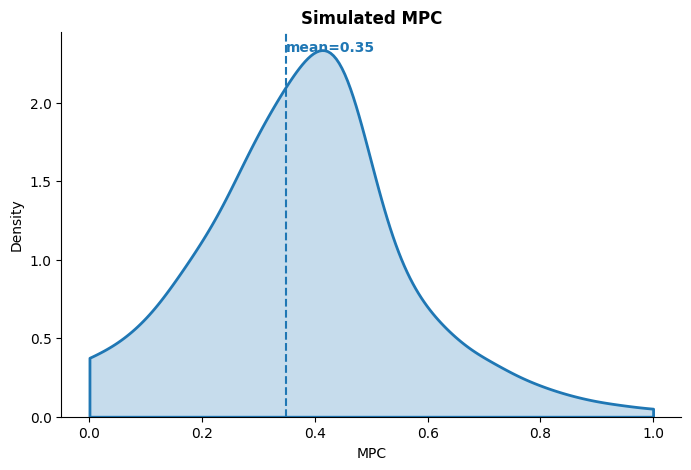

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

panel = pd.read_csv(paths["analysis_dir"] / "household_mpc_panel.csv")
mpc_col = "cmpc_2p"  # match the column you analysed
values = panel[mpc_col].replace([float("inf"), float("-inf")], pd.NA).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(values, fill=True, color="#1f77b4", linewidth=2, ax=ax, clip=[0,1])
mean_val = values.mean()
ax.axvline(mean_val, color="#1f77b4", linestyle="--")
ax.text(mean_val, ax.get_ylim()[1] * 0.95, f"mean={mean_val:.2f}", color="#1f77b4", fontweight="bold")
ax.set_title("Simulated MPC", fontweight="bold")
ax.set_xlabel("MPC")
ax.set_ylabel("Density")
sns.despine()
plt.show()


In [ ]:
from src.visual_helpers import plot_household_wealth_ratio_distributions
plot_household_wealth_ratio_distributions(model=model, country_code='FRA', clip_quantiles=[0.05,0.95])

# Optional: IRF to shock

In [ ]:
make_irf = True
# uses benchmark

if make_irf:

    from pathlib import Path
    from run_irf_experiment import run_irf_experiment
    from macromodel.utils.prehooks.irf_shocks import ShockSpec
    from IPython.display import display, HTML
    from src.irf_analysis import plot_irfs
    
    shock_specs = (
        ShockSpec(
            name="gov_cons_10pct",
            kind="government_consumption",
            period=20,          # zero-based simulation period
            magnitude=0.10,     # +10%
            duration=1,
            mode="multiplicative",
        ),
        ShockSpec(
            name="policy_rate_100bp",
            kind="policy_rate",
            period=20,
            magnitude=0.01,     # +100bp annualized; converted to per-period internally
            duration=4,
            mode="additive",
        ),
        ShockSpec(
            name="income_tax_1pp",
            kind="income_tax",
            period=20,
            magnitude=0.01,     # +1 percentage point
            duration=4,
            mode="additive",
        ),
        ShockSpec(
            name="unemp_2pp",
            kind="unemployment_rate",
            period=20,
            magnitude=0.02,     # separates about 2% of labour force
            duration=4,
            mode="additive",
        ),
    )
    
    outputs = run_irf_experiment(
        seeds=[12, 13, 14, 15, 16, 17, 18, 19, 20],
        t_max=50,
        shock_specs=shock_specs,
        horizon_periods=12,
        output_dir=Path("run_model/data/output_data/irf-experiment"),
        country_iso3="FRA",
        n_jobs=4,
    )
    
    from pathlib import Path
    from IPython.display import display, HTML
    
    analysis_dir = Path(outputs["analysis_dir"])
    plot_files = sorted((analysis_dir / "plots").glob("*.html"))
    pct_plot_files = sorted((analysis_dir / "plots_pct").glob("*.html"))
    
    plot_files = sorted((analysis_dir / "plots").glob("*.html"))
    pct_plot_files = sorted((analysis_dir / "plots_pct").glob("*.html"))
    
    
    fig = plot_irfs(
        analysis_dir,
        shocks=["policy_rate_100bp"],
        variables="household_consumption",
        percent=True,
    )
    fig.show()
    
    fig = plot_irfs(
        analysis_dir,
        shocks=["income_tax_1pp"],
        variables="household_consumption",
        percent=True,
    )
    fig.show()
    
    
    fig = plot_irfs(
        analysis_dir,
        shocks=["unemp_2pp"],
        variables="household_consumption",
        percent=True,
    )
    fig.show()

# Appendix

Scratch diagnostics and notes. These cells are not part of the main top-to-bottom workflow.


In [ ]:
# # Shared appendix variables
# country_iso3 = cfg.country_iso3
# country = country_iso3
# year = data_config.year
# quarter = data_config.quarter
# time_unit = data_config.time_unit
# periods_per_year = 12 // time_unit


### Exploratory firm diagnostics


In [ ]:
# [print(col) for col in model.countries["FRA"].firms.ts.get_keys()]

In [ ]:
from src.visual_helpers import plot_agent_timeseries

fig, info = plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    variables=[
        "equity",
        "inventory",
        "intermediate_inputs_stock_value",
        "capital_inputs_stock_value",
        "labour_inputs",
        "total_credit_exposure",
        "deposits",
    ],
    no_cols=2,
    # condition="equity < 0",
    agent_id=[547],
    return_info=True,
    show=False,
    base_height=260,
    base_width=500,
)

fig.show()
# info

In [ ]:
fig, info = plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    variables=[
        ["demand",
        "real_amount_sold"],
        ["estimated_demand",
        "production"],
        "real_excess_demand",
        "nominal_amount_sold_in_lcu",
        "price",
        "unit_costs",
        "profits",
        "taxes_paid_on_production",
        "corporate_taxes_paid",
        "activity_finance_available",
        "activity_finance_hard_obligations",
        "used_intermediate_inputs_costs",
        "used_capital_inputs_costs",
        "capital_depreciation_costs",
        "received_short_term_credit",
        "received_long_term_credit",
        "received_debt_rollover_credit",
        "received_credit",
        "scheduled_debt_service",
    ],
    no_cols=2,
    # condition="equity < 0",
    agent_id=[543],
    return_info=True,
    show=False,
    base_height=260,
    base_width=600,
)

fig.show()
# info

In [ ]:
# Random sample of 100 units without replacement
firms_list = np.random.choice(np.arange(1000), size=100, replace=False).tolist()
firms_list = np.arange(382,435).tolist()

# fig, info = plot_agent_timeseries(
#     benchmark.model,
#     "FRA",
#     "firms",
#     variables=[
#         "price",
#         "unit_costs",
#         "profits",
#         "real_amount_sold",
#         "production",
#     ],
#     no_cols=2,
#     # condition="equity < 0",
#     agent_id=firms_list,
#     return_info=True,
#     show=False,
#     base_height=260,
#     base_width=800,
# )

# fig.show()

fig, info = plot_agent_timeseries(
    model,
    "FRA",
    "firms",
    variables=[
        "price",
        "unit_costs",
        "profits",
        "real_amount_sold",
        "production",
    ],
    no_cols=2,
    # condition="equity < 0",
    agent_id=firms_list,
    return_info=True,
    show=False,
    base_height=260,
    base_width=800,
)

fig.show()
# info
# info

### Exploratory household diagnostics


In [ ]:
# model.countries['FRA'].households.ts.get_keys()

In [ ]:
from src.visual_helpers import plot_agent_timeseries

fig = plot_agent_timeseries(
    model,
    "FRA",
    "households",
    [["target_consumption", "consumption", "amount_bought"],
     ["wealth_real_assets", "wealth_main_residence", "wealth_other_properties", "wealth_other_real_assets", "wealth_deposits", "wealth_other_financial_assets", "wealth_financial_assets"],
     ['wealth', 'net_wealth', 'debt'],
     ["expected_income", "expected_income_employee", "expected_income_social_transfers", "expected_income_financial_assets"],
     ["income", "income_employee", "income_social_transfers", "income_rental", "income_financial_assets"],
     ['target_investment', 'investment', 'total_investment', 'total_investment_before_vat'],
     ],
    # panel_titles=["Target vs bought"],
    agg="sum",          # or "mean"/"median"
    no_cols=2,
    show_legend=True,
    show=False,
    base_height=300,
    base_width=600,
)

fig.show()

In [ ]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "households",
    [
        ["mortgage_debt", "consumption_loan_debt", "debt"],
        ["target_mortgage", "received_mortgages", "received_consumption_loans"],
        ["debt_installments", "interest_paid_on_deposits", "interest_paid_on_loans", "interest_paid"],
        ["real_amount_sold", "real_amount_sold_to_FRA", "real_amount_sold_to_ROW", "nominal_amount_sold_in_lcu", "nominal_amount_sold_in_lcu_to_FRA", "nominal_amount_sold_in_lcu_to_ROW"],
        ["nominal_amount_spent_in_usd", "nominal_amount_spent_in_usd_to_FRA", "nominal_amount_spent_in_usd_to_ROW", "nominal_amount_spent_in_lcu", "nominal_amount_spent_in_lcu_to_FRA", "nominal_amount_spent_in_lcu_to_ROW"],
        ["real_amount_bought", "real_amount_bought_from_FRA", "real_amount_bought_from_ROW"],
    ],
    agg="sum",
    no_cols=2,
    show_legend=True,
    show=False,
    base_height=300,
    base_width=600,
)

fig.show()

In [ ]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "households",
    ['price_paid_for_property',
      ['rent', 'rent_imputed'],
      'max_price_willing_to_pay', 'max_rent_willing_to_pay'
      ],
    # panel_titles=["Target vs bought"],
    agg="sum",          # or "mean"/"median"
    no_cols=2,
    show_legend=True,
    show=False,
    base_height=300,
    base_width=600,
)

fig.show() 




In [ ]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "households",
    [
        ["mortgage_debt", "consumption_loan_debt"],
        "price_paid_for_property", "wealth_real_assets", "wealth_main_residence", "wealth_other_properties", "wealth_other_real_assets", "wealth_deposits", "wealth_other_financial_assets", "wealth_financial_assets",
     ],
    # panel_titles=["Target vs bought"],
    agg="sum",          # or "mean"/"median"
    no_cols=4,
    show_legend=True,
    show=False,
    base_height=300,
    base_width=400,
)

fig.show() 




In [ ]:
fig = plot_agent_timeseries(
    model,
    "FRA",
    "households",
    [
        "income_rental", "wealth_real_assets", "wealth_main_residence", "wealth_other_properties", "wealth_other_real_assets", "wealth_deposits", "wealth_other_financial_assets", "wealth_financial_assets",
     ],
    # panel_titles=["Target vs bought"],
    agg="sum",          # or "mean"/"median"
    no_cols=4,
    show_legend=True,
    show=False,
    # condition="wealth_other_financial_assets<0",
    agent_id=['5169'],
    base_height=300,
    base_width=400,
)

fig.show() 




In [ ]:
# model.countries['FRA'].households.ts.get_keys()

### Government consumption behaviour

| Setter | Total-consumption anchor | Growth source | Uses exogenous gov path? | Uses `expected_growth`? | Price adjustment | Sector allocation | Key assumption / caveat |
|---|---|---|---|---|---|---|---|
| `AutoregressiveGovernmentConsumptionSetter` | Forecasted total government consumption `C_t` from AR on historical total consumption | `ManualAutoregForecaster()` on `historic_total_consumption` or `log(historic_total_consumption)` in `macromodel/agents/government_entities/func/consumption.py:171` | No, not directly for the forecast itself; exogenous pre-sample history can be included in `historic_total_consumption` via `macromodel/agents/government_entities/government_entities.py:212` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:205` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:209` | Total is forecasted, but sector shares drift through recursive reweighting with relative prices |
| `ConstantGrowthGovernmentConsumptionSetter` | Previous desired government consumption vector scaled forward each period | Either configured `default_growth`, or estimated once as mean log growth of `historic_total_consumption` in `macromodel/agents/government_entities/func/consumption.py:277` | No | No | Yes: when history exists, uses `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:287` | Implicitly last period’s desired nominal vector, because the whole vector is scaled in `macromodel/agents/government_entities/func/consumption.py:290` | “Constant growth” is literal after initialization; estimated growth is log-growth but later applied as arithmetic growth `(1 + g)`, which is not fully consistent |
| `ExogenousGovernmentConsumptionSetter` | Exogenous total real government consumption path `exogenous_total_consumption[t]` | No endogenous growth estimation; the level comes directly from exogenous national accounts path | Yes: `self.exogenous.national_accounts_during["Real Government Consumption (Value)"]` passed from `macromodel/country/country.py:934` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:477` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:481` | Aggregate path is exogenous, but composition is still endogenous via lagged shares; if exogenous data ends, it raises an error; if exogenous path is missing entirely, it falls back to configured `default_growth` |


### Readers

In [ ]:
# gov consumption estimation

from macromodel.forecaster.forecaster import ManualAutoregForecaster

country_obj = model.countries[cfg.country_iso3]
ge = country_obj.government_entities

exog_before = country_obj.exogenous.national_accounts_before["Real Government Consumption (Value)"].values.flatten()

historic_ppi = np.array(country_obj.economy.ts.historic("ppi")).flatten()

historic_total_consumption = np.concatenate(
    (
        exog_before[-country_obj.forecasting_window:],
        np.array(ge.ts.historic("total_consumption")).flatten() / historic_ppi,
    )
)

series = np.log(historic_total_consumption)
series = series[np.isfinite(series)]

var = ManualAutoregForecaster.rfvar3(series, np.ones((len(series), 1)))

phi = var["By"][0][0][0]
intercept = var["Bx"][0]
resid_std = np.sqrt(np.var(var["u"]))
n_obs = len(series) - 1

phi, intercept, resid_std, n_obs


In [ ]:
# from src.helpers import fit_social_benefits_arx_diagnostics
from macro_data.readers.default_readers import DataReaders
from macro_data.readers import AGGREGATED_INDUSTRIES, ALL_INDUSTRIES

country_names = data_config.countries
industries = AGGREGATED_INDUSTRIES if data_config.aggregate_industries else ALL_INDUSTRIES
scale_dict = {country: data_config.country_configs[country].scale for country in country_names}
proxy_country_dict = {
    country: data_config.country_configs[country].eu_proxy_country
    for country in data_config.countries
    if not country.is_eu_country
}

readers = DataReaders.from_raw_data(
    raw_data_path=cfg.raw_data_path,
    country_names=country_names,
    simulation_year=data_config.year,
    scale_dict=scale_dict,
    industries=industries,
    aggregate_industries=data_config.aggregate_industries,
    prune_date=data_config.prune_date,
    force_single_hfcs_survey=False,
    single_icio_survey=True,
    proxy_country_dict=proxy_country_dict,
    use_disagg_can_2014_reader=data_config.can_disaggregation,
    use_provincial_can_reader=False,
    regions_dict=None,
    allow_missing_emissions=False,
)


In [ ]:
quarter_key = f"{year}-Q{quarter}"

firm_rates_annual = readers.ecb_reader.get_firm_rates(country_iso3)
hh_cons_rates_annual = readers.ecb_reader.get_household_consumption_rates(country_iso3)
hh_mort_rates_annual = readers.ecb_reader.get_household_mortgage_rates(country_iso3)
policy_rates_annual = readers.policy_rates.get_policy_rates(country_iso3)

firm_rates_annual.loc[quarter_key]
hh_cons_rates_annual.loc[quarter_key]
hh_mort_rates_annual.loc[quarter_key]
policy_rates_annual.loc[quarter_key, "Policy Rate"]


In [ ]:
quarter_key = f"{2022}-Q{quarter}"
banks = data.synthetic_countries[country].banks

firm_rate_annual = readers.ecb_reader.get_firm_rates(country).loc[quarter_key].iloc[0]
hh_cons_rate_annual = readers.ecb_reader.get_household_consumption_rates(country).loc[quarter_key].iloc[0]
hh_mort_rate_annual = readers.ecb_reader.get_household_mortgage_rates(country).loc[quarter_key].iloc[0]
policy_rate_annual = readers.policy_rates.get_policy_rates(country).loc[quarter_key, "Policy Rate"].iloc[0]

comparison = pd.DataFrame(
    {
        "raw_annual_reader": [
            float(firm_rate_annual),
            float(hh_cons_rate_annual),
            float(hh_mort_rate_annual),
            float(policy_rate_annual),
            float(policy_rate_annual),
        ],
        "expected_per_period": [
            float(firm_rate_annual) / periods_per_year,
            float(hh_cons_rate_annual) / periods_per_year,
            float(hh_mort_rate_annual) / periods_per_year,
            float(policy_rate_annual) / periods_per_year,
            float(policy_rate_annual) / periods_per_year,
        ],
        "stored_in_data": [
            float(banks.firm_rate),
            float(banks.hh_consumption_rate),
            float(banks.hh_mortgage_rate),
            float(banks.bank_data["Interest Rates on Firm Deposits"].iloc[0]),
            float(banks.bank_data["Interest Rates on Household Deposits"].iloc[0]),
        ],
    },
    index=[
        "firm loan rate",
        "hh consumption loan rate",
        "mortgage rate",
        "firm deposit rate",
        "hh deposit rate",
    ],
)

comparison["difference"] = comparison["stored_in_data"] - comparison["expected_per_period"]
comparison


In [ ]:
quarter_key = f"{year}-Q{quarter}"
def scalar(x):
    if isinstance(x, pd.DataFrame):
        return x.iloc[0, 0]
    if isinstance(x, pd.Series):
        return x.iloc[0]
    return x

synthetic_country = data.synthetic_countries[country]
banks = synthetic_country.banks
cb_data = synthetic_country.central_bank.central_bank_data

policy_rate_raw_annual = float(scalar(readers.policy_rates.get_policy_rates(country).loc[quarter_key, ["Policy Rate"]]))
firm_loan_raw_annual = float(scalar(readers.ecb_reader.get_firm_rates(country).loc[quarter_key]))
hh_cons_loan_raw_annual = float(scalar(readers.ecb_reader.get_household_consumption_rates(country).loc[quarter_key]))
mortgage_raw_annual = float(scalar(readers.ecb_reader.get_household_mortgage_rates(country).loc[quarter_key]))

rows = [
    ["policy rate from reader", policy_rate_raw_annual, policy_rate_raw_annual / periods_per_year, None],
    ["central bank stored policy_rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(cb_data[["policy_rate"]])) if "policy_rate" in cb_data.columns else None],
    ["central bank stored smooth_policy_rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(cb_data[["smooth_policy_rate"]])) if "smooth_policy_rate" in cb_data.columns else None],
    ["firm deposit rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(banks.bank_data[["Interest Rates on Firm Deposits"]]))],
    ["household deposit rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(banks.bank_data[["Interest Rates on Household Deposits"]]))],
    ["firm loan rate", firm_loan_raw_annual, firm_loan_raw_annual / periods_per_year, float(banks.firm_rate)],
    ["hh consumption loan rate", hh_cons_loan_raw_annual, hh_cons_loan_raw_annual / periods_per_year, float(banks.hh_consumption_rate)],
    ["mortgage rate", mortgage_raw_annual, mortgage_raw_annual / periods_per_year, float(banks.hh_mortgage_rate)],
]

df_rates = pd.DataFrame(rows, columns=["rate", "raw_annual", "expected_per_period", "stored_in_data"])
df_rates["stored_minus_expected"] = df_rates["stored_in_data"] - df_rates["expected_per_period"]

print(f"country={country}, quarter={quarter_key}, time_unit={data_config.time_unit}, periods_per_year={periods_per_year}")
print(df_rates.round(6).to_string(index=False))


In [ ]:
start_period = pd.Period(f"{year}Q{quarter}", freq="Q")
init_period = start_period - 1
init_key = f"{init_period.year}-Q{init_period.quarter}"
synthetic_country = data.synthetic_countries[country]
cb_data = synthetic_country.central_bank.central_bank_data
banks = synthetic_country.banks

policy_rate_init_annual = float(readers.policy_rates.get_policy_rates(country).loc[init_key, ["Policy Rate"]].iloc[0, 0])
policy_rate_init_period = policy_rate_init_annual / periods_per_year

check = pd.DataFrame(
    [
        ["pre-start policy rate from reader", policy_rate_init_annual, policy_rate_init_period, None],
        ["stored smooth_policy_rate", None, policy_rate_init_period, float(cb_data["smooth_policy_rate"].iloc[0]) if "smooth_policy_rate" in cb_data.columns else None],
        ["stored legacy policy_rate", None, policy_rate_init_period, float(cb_data["policy_rate"].iloc[0]) if "policy_rate" in cb_data.columns else None],
        ["firm deposit rate", None, policy_rate_init_period, float(banks.bank_data["Interest Rates on Firm Deposits"].iloc[0])],
        ["household deposit rate", None, policy_rate_init_period, float(banks.bank_data["Interest Rates on Household Deposits"].iloc[0])],
    ],
    columns=["rate", "raw_annual", "expected_per_period", "stored_in_data"],
)

check["stored_minus_expected"] = check["stored_in_data"] - check["expected_per_period"]
print(f"start={start_period}, init={init_key}, time_unit={data_config.time_unit}")
print(check.round(6).to_string(index=False))


# Notes: CBC7

- UK baseline (lots of small edits)
- Synthetic population script mimicking HFCS for the UK. Testing it currently.
- Marcela updated the starting year
- Monte Carlo runs + dashboard
- prehooks for shock
- Marcela tested 1-to-1 simulation


In [ ]:
# CBC7 issues

# UK baseline (lots of small edits)
# Synthetic population script mimicking HFCS for the UK. Testing it currently.
# Marcela updated the starting year
# Monte Carlo runs + dashboard
# prehooks for shock
# Marcela tested 1-to-1 simulation
